<!-- # 04 — Risk Analysis

Aggregate conflict data to identify spatial hotspots, high-risk aircraft pairs, temporal patterns, and sector-level risk metrics that an ops analyst would report to a supervisor. -->

## 1. Load Data

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

df_states    = pd.read_csv("../data/raw_states.csv",  parse_dates=["time_utc"])
df_conflicts = pd.read_csv("../data/conflicts.csv")

print(f"States:    {len(df_states)} records")
print(f"Conflicts: {len(df_conflicts)} events")

has_conflicts = len(df_conflicts) > 0 and "severity" in df_conflicts.columns
if not has_conflicts:
    print("\nNo conflicts in dataset. Risk analysis sections will generate placeholder outputs.")

States:    872 records
Conflicts: 400 events


## 2. Spatial Hotspot Analysis

Map conflict midpoints to identify which areas of the sector carry the most risk.

In [2]:
os.makedirs("../outputs", exist_ok=True)

# ── Folium interactive map ─────────────────────────────────────────────────
center_lat = (df_states["lat"].mean())
center_lon = (df_states["lon"].mean())
m = folium.Map(location=[center_lat, center_lon], zoom_start=7,
               tiles="CartoDB dark_matter")

# All aircraft positions (light blue dots)
for _, row in df_states.sample(min(500, len(df_states))).iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=2, color="#4fc3f7", fill=True, fill_opacity=0.4,
        popup=f"{row['callsign']} | {row['altitude_ft']:.0f} ft | {row['velocity_kts']:.0f} kts"
    ).add_to(m)

# Conflict events
if has_conflicts:
    color_map = {"CRITICAL": "red", "WARNING": "orange", "ADVISORY": "yellow"}
    for _, row in df_conflicts.iterrows():
        folium.CircleMarker(
            location=[row["lat_midpoint"], row["lon_midpoint"]],
            radius=8 + row.get("risk_score", 0) / 10,
            color=color_map.get(row["severity"], "gray"),
            fill=True, fill_opacity=0.7,
            popup=(f"<b>{row['severity']}</b><br>"
                   f"{row['callsign_a']} / {row['callsign_b']}<br>"
                   f"H: {row['horizontal_dist_nm']:.2f} NM  V: {row['vertical_dist_ft']:.0f} ft<br>"
                   f"Risk: {row.get('risk_score', 'N/A')}")
        ).add_to(m)

    # Heatmap layer
    heat_data = df_conflicts[["lat_midpoint","lon_midpoint"]].values.tolist()
    HeatMap(heat_data, radius=25, blur=20, name="Conflict Heatmap").add_to(m)
    folium.LayerControl().add_to(m)

map_path = "../outputs/04_conflict_map.html"
m.save(map_path)
print(f"Interactive map saved -> {map_path}")
print("Open in a browser to explore.")

Interactive map saved -> ../outputs/04_conflict_map.html
Open in a browser to explore.


## 3. Sector-Level Risk Metrics

Compute aggregate statistics that would appear in an ops analysis briefing.

In [3]:
n_aircraft   = df_states["icao24"].nunique()
n_snapshots  = df_states["time"].nunique()
n_conflicts  = len(df_conflicts)

# Conflict rate per aircraft-pair-snapshot (normalized exposure metric)
import itertools
avg_ac = n_aircraft / max(n_snapshots, 1)
possible_pairs_per_snap = avg_ac * (avg_ac - 1) / 2
total_pair_checks = possible_pairs_per_snap * n_snapshots
conflict_rate = n_conflicts / max(total_pair_checks, 1) * 100

print("=" * 45)
print("  SECTOR RISK SUMMARY")
print("=" * 45)
print(f"  Aircraft tracked:          {n_aircraft}")
print(f"  Snapshots analyzed:        {n_snapshots}")
print(f"  Total conflict events:     {n_conflicts}")
print(f"  Conflict rate:             {conflict_rate:.3f}%")

if has_conflicts:
    print(f"  Mean risk score:           {df_conflicts['risk_score'].mean():.1f}/100")
    print(f"  Peak risk score:           {df_conflicts['risk_score'].max():.1f}/100")
    print(f"  Critical events:           {(df_conflicts['severity']=='CRITICAL').sum()}")
    print(f"  Warning events:            {(df_conflicts['severity']=='WARNING').sum()}")
    print(f"  Advisory events:           {(df_conflicts['severity']=='ADVISORY').sum()}")
print("=" * 45)

  SECTOR RISK SUMMARY
  Aircraft tracked:          153
  Snapshots analyzed:        5
  Total conflict events:     400
  Conflict rate:             17.665%
  Mean risk score:           56.7/100
  Peak risk score:           80.1/100
  Critical events:           199
  Warning events:            62
  Advisory events:           139


## 4. High-Risk Aircraft Pairs

In [4]:
if has_conflicts:
    pair_stats = (df_conflicts
        .assign(pair=lambda d: d.apply(
            lambda r: tuple(sorted([r["callsign_a"], r["callsign_b"]])), axis=1))
        .groupby("pair")
        .agg(
            n_events=("severity", "count"),
            max_risk=("risk_score", "max"),
            worst_severity=("severity", lambda x: x.iloc[0]),
            min_h_sep=("horizontal_dist_nm", "min"),
            min_v_sep=("vertical_dist_ft", "min"),
        )
        .sort_values("max_risk", ascending=False)
        .head(10)
    )
    print("Top 10 highest-risk aircraft pairs:")
    print(pair_stats.to_string())
else:
    print("No conflict pairs to analyze.")

Top 10 highest-risk aircraft pairs:
                  n_events  max_risk worst_severity  min_h_sep  min_v_sep
pair                                                                     
(N581RS, SWA22)          2     80.08       CRITICAL      0.005       25.0
(AAL127, AAL127)         1     80.00       CRITICAL      0.000        0.0
(N735PR, N735PR)         1     80.00       CRITICAL      0.000        0.0
(N686CA, N686CA)         1     80.00       CRITICAL      0.000        0.0
(N690AP, N690AP)         1     80.00       CRITICAL      0.000        0.0
(N7074V, N7074V)         1     80.00       CRITICAL      0.000        0.0
(N72338, N72338)         1     80.00       CRITICAL      0.000        0.0
(N733ES, N733ES)         1     80.00       CRITICAL      0.000        0.0
(N733WU, N733WU)         1     80.00       CRITICAL      0.000        0.0
(N734ZY, N734ZY)         1     80.00       CRITICAL      0.000        0.0


## 5. Risk by Altitude Band

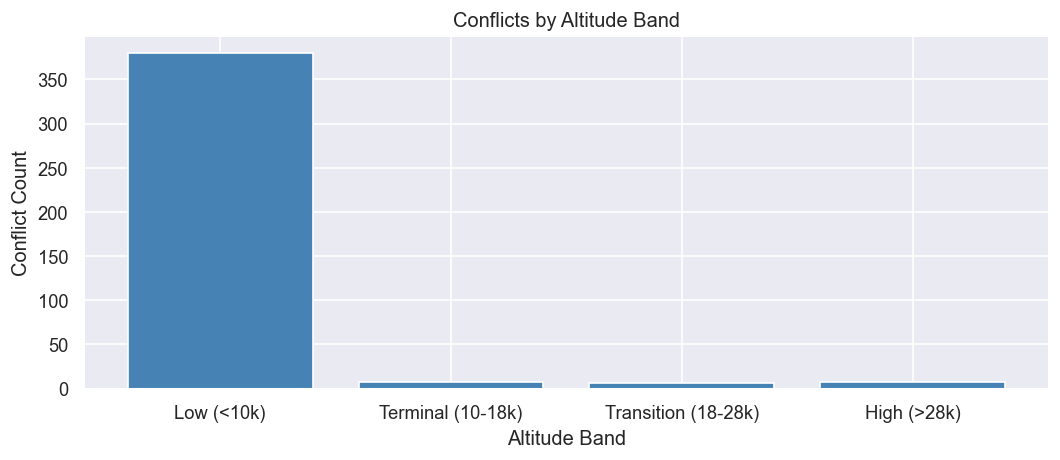

In [5]:
if has_conflicts and len(df_states) > 0:
    # Join conflict midpoint altitudes from nearest state
    fig, ax = plt.subplots(figsize=(9, 4))

    # Average altitude of conflicting aircraft
    def get_alt(icao):
        rows = df_states[df_states["icao24"] == icao]["altitude_ft"]
        return rows.mean() if len(rows) > 0 else np.nan

    avg_alts = df_conflicts.apply(
        lambda r: (get_alt(r["icao_a"]) + get_alt(r["icao_b"])) / 2, axis=1)
    df_conflicts["avg_alt_ft"] = avg_alts

    bins   = [0, 10000, 18000, 28000, 60000]
    labels = ["Low (<10k)", "Terminal (10-18k)", "Transition (18-28k)", "High (>28k)"]
    df_conflicts["alt_band"] = pd.cut(df_conflicts["avg_alt_ft"], bins=bins, labels=labels)

    band_counts = df_conflicts["alt_band"].value_counts().reindex(labels, fill_value=0)
    ax.bar(band_counts.index, band_counts.values, color="steelblue", edgecolor="white")
    ax.set_xlabel("Altitude Band")
    ax.set_ylabel("Conflict Count")
    ax.set_title("Conflicts by Altitude Band")

    plt.tight_layout()
    plt.savefig("../outputs/04_alt_band_risk.png", bbox_inches="tight")
    plt.show()
else:
    print("Insufficient data for altitude band analysis.")